In [1]:

from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from scipy.stats import randint, uniform
from sklearn.ensemble import HistGradientBoostingRegressor

random_state = 42
np.random.seed(random_state)

In [2]:
pd.set_option('display.max_columns', None)

df = pd.read_csv('../../data/processed_player_data_v2.csv')

df.head()

,Game ID,player_rating,opponent_rating,player_white,opening_ply,elo_delta_ratio,opening_frequency,player_centipawn_loss,opponent_centipawn_loss,time_control,time_control_encoded,player_username,opponent_username,opening_familiarity,player_rapid_rating,opponent_rapid_rating,player_rapid_games,opponent_rapid_games,player_blitz_rating,opponent_blitz_rating,player_blitz_games,opponent_blitz_games,player_bullet_rating,opponent_bullet_rating,player_bullet_games,opponent_bullet_games,player_total_games,opponent_total_games,player_play_time_secs,opponent_play_time_secs,player_avg_game_secs,opponent_avg_game_secs,player_blitz_vs_rapid,player_bullet_vs_blitz,player_bullet_vs_rapid,opponent_blitz_vs_rapid,opponent_bullet_vs_blitz,opponent_bullet_vs_rapid,player_rapid_ratio,player_blitz_ratio,player_bullet_ratio,opponent_rapid_ratio,opponent_blitz_ratio,opponent_bullet_ratio,rapid_rating_gap,blitz_rating_gap,total_games_gap,rapid_games_gap,play_time_gap
0,J7Xvjkte,1441,1559,1,4,-0.078667,2,32,87,rapid,3,jerzypa2,timothei,1,1467.0,1659.0,965,2657,1155.0,1385.0,142,952,982.0,1018.0,26,8,1251,3980,1016708,3090613,812.716227,776.535930,-312.0,-173.0,-485.0,-274.0,-367.0,-641.0,0.771383,0.113509,0.020783,0.667588,0.239196,0.002010,-192.0,-230.0,-2729,-1692,-2073905
1,SSzpi7W1,1258,1567,1,6,-0.218761,2,43,6,rapid,3,nephi,veky,1,1221.0,1689.0,261,3466,1184.0,1393.0,6,9327,1284.0,1500.0,3,4452,333,18177,272224,6513529,817.489489,358.339055,-37.0,100.0,63.0,-296.0,107.0,-189.0,0.783784,0.018018,0.009009,0.190681,0.513121,0.244925,-468.0,-209.0,-17844,-3205,-6241305
2,NHpcYm3r,1697,1712,1,7,-0.008800,2,11,42,rapid,3,ronuh,kuramateca,1,NaN,1573.0,0,9230,NaN,1357.0,0,119,NaN,1330.0,0,2,0,9358,0,7732082,NaN,826.253687,NaN,NaN,NaN,-216.0,-27.0,-243.0,NaN,NaN,NaN,0.986322,0.012716,0.000214,NaN,NaN,-9358,-9230,-7732082
3,Nrzmgzmn,1978,1868,1,5,0.057202,2,21,53,rapid,3,anaya44,jeoda,1,NaN,1786.0,0,2172,NaN,1640.0,0,29436,NaN,955.0,0,1,0,31613,0,16836309,NaN,532.575491,NaN,NaN,NaN,-146.0,-685.0,-831.0,NaN,NaN,NaN,0.068706,0.931136,0.000032,NaN,NaN,-31613,-2172,-16836309
4,xMuFsnC6,2073,1816,1,2,0.132168,2,35,50,rapid,3,marc_robin,deraincharles,1,2158.0,2029.0,226,790,2119.0,1841.0,31948,2351,1500.0,1609.0,0,1357,32177,4567,14125375,1843793,438.989806,403.720823,-39.0,-619.0,-658.0,-188.0,-232.0,-420.0,0.007024,0.992883,0.000000,0.172980,0.514780,0.297132,129.0,278.0,27610,-564,12281582


In [3]:
numeric_cols     = df.select_dtypes(include='number').columns.tolist()
non_numeric_cols = df.select_dtypes(exclude='number').columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):")
for col in numeric_cols:
    print(f"  {col}  [{df[col].dtype}]  nulls: {df[col].isnull().sum()}")

print(f"\nNon-numeric columns ({len(non_numeric_cols)}):")
for col in non_numeric_cols:
    print(f"  {col}  [{df[col].dtype}]  nulls: {df[col].isnull().sum()}  unique: {df[col].nunique()}")

Numeric columns (45):
  player_rating  [int64]  nulls: 0
  opponent_rating  [int64]  nulls: 0
  player_white  [int64]  nulls: 0
  opening_ply  [int64]  nulls: 0
  elo_delta_ratio  [float64]  nulls: 0
  opening_frequency  [int64]  nulls: 0
  player_centipawn_loss  [int64]  nulls: 0
  opponent_centipawn_loss  [int64]  nulls: 0
  time_control_encoded  [int64]  nulls: 0
  opening_familiarity  [int64]  nulls: 0
  player_rapid_rating  [float64]  nulls: 5650
  opponent_rapid_rating  [float64]  nulls: 5650
  player_rapid_games  [int64]  nulls: 0
  opponent_rapid_games  [int64]  nulls: 0
  player_blitz_rating  [float64]  nulls: 5650
  opponent_blitz_rating  [float64]  nulls: 5650
  player_blitz_games  [int64]  nulls: 0
  opponent_blitz_games  [int64]  nulls: 0
  player_bullet_rating  [float64]  nulls: 5650
  opponent_bullet_rating  [float64]  nulls: 5650
  player_bullet_games  [int64]  nulls: 0
  opponent_bullet_games  [int64]  nulls: 0
  player_total_games  [int64]  nulls: 0
  opponent_total_g

In [4]:
null_stat_players = df[df['player_rapid_rating'].isnull()]['player_username'].dropna().unique()
print(f"Example usernames with null stats (deleted/banned accounts ?):")
for u in null_stat_players[:5]:
    print(f"  {u}")

#This is the return value when queries for one of the users.

#{"id":"jacobboehme","username":"JacobBoehme","disabled":true} <= we don't know why the account is closed


Example usernames with null stats (deleted/banned accounts ?):
  ronuh
  anaya44
  lordofking
  rodolfos
  jacobboehme


I have 37274 rows, highest null count is 10328.
Null values are typically in columns related to rating
I am thkinking of these options:
-Fill in the missing data
-Drop all of the rows that have null, if I would drop these rows I would lose 1/4 of the data
-Drop the columns with 25% missing data
-Maybe make a feature out of missing data ?

My assumption is that missing data is due to the closure of account. 
Accounts can be closed manually or banned due to cheating.

According to the presentations in 04_Data_preparation is data MNAR or MAR ?
For cheaters I guess so, as cheater will probably have higher elo.



In [5]:
# We do not need gamed id, player usernames and time control for our analysis, so we can drop those columns. Time control is encoded in time control encoded, but since it has only 1 unique value, we can drop it as well.
df = df.drop(columns=['Game ID', 'player_username', 'opponent_username', 'time_control','time_control_encoded','opponent_centipawn_loss'])

#Should I also drop opponent centipawn loss ? it highly correlated to player centipawn loss.
#Based on business logic I will drop it. 

Also if player profile is disabled, other columns are influenced like total games (fetching script assumes then that total games are 0)

After considering couple of options of dropping or not dropping. I will make a feature called player_profile_disabled or something like that. I will just handle the missing data by imputing the median. This data will be served into my first iteration of models.

In [6]:
rating_cols = ['player_rapid_rating', 'player_blitz_rating', 'player_bullet_rating']
opponent_rating_cols = ['opponent_rapid_rating', 'opponent_blitz_rating', 'opponent_bullet_rating']

df['player_profile_disabled']   = df[rating_cols].isnull().any(axis=1).astype(int)
df['opponent_profile_disabled']  = df[opponent_rating_cols].isnull().any(axis=1).astype(int)

print(f"player_profile_disabled: {df['player_profile_disabled'].sum()}  active: {(df['player_profile_disabled']==0).sum()}")
print(f"opponent_profile_disabled: {df['opponent_profile_disabled'].sum()}  active: {(df['opponent_profile_disabled']==0).sum()}")

player_profile_disabled: 5650  active: 31624
opponent_profile_disabled: 5650  active: 31624


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37274 entries, 0 to 37273
Data columns (total 45 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   player_rating              37274 non-null  int64  
 1   opponent_rating            37274 non-null  int64  
 2   player_white               37274 non-null  int64  
 3   opening_ply                37274 non-null  int64  
 4   elo_delta_ratio            37274 non-null  float64
 5   opening_frequency          37274 non-null  int64  
 6   player_centipawn_loss      37274 non-null  int64  
 7   opening_familiarity        37274 non-null  int64  
 8   player_rapid_rating        31624 non-null  float64
 9   opponent_rapid_rating      31624 non-null  float64
 10  player_rapid_games         37274 non-null  int64  
 11  opponent_rapid_games       37274 non-null  int64  
 12  player_blitz_rating        31624 non-null  float64
 13  opponent_blitz_rating      31624 non-null  flo

In [8]:
X = df.drop(columns=['player_centipawn_loss'])
y = df['player_centipawn_loss']

In [9]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [10]:
X_train.columns

Index(['player_rating', 'opponent_rating', 'player_white', 'opening_ply',
       'elo_delta_ratio', 'opening_frequency', 'opening_familiarity',
       'player_rapid_rating', 'opponent_rapid_rating', 'player_rapid_games',
       'opponent_rapid_games', 'player_blitz_rating', 'opponent_blitz_rating',
       'player_blitz_games', 'opponent_blitz_games', 'player_bullet_rating',
       'opponent_bullet_rating', 'player_bullet_games',
       'opponent_bullet_games', 'player_total_games', 'opponent_total_games',
       'player_play_time_secs', 'opponent_play_time_secs',
       'player_avg_game_secs', 'opponent_avg_game_secs',
       'player_blitz_vs_rapid', 'player_bullet_vs_blitz',
       'player_bullet_vs_rapid', 'opponent_blitz_vs_rapid',
       'opponent_bullet_vs_blitz', 'opponent_bullet_vs_rapid',
       'player_rapid_ratio', 'player_blitz_ratio', 'player_bullet_ratio',
       'opponent_rapid_ratio', 'opponent_blitz_ratio', 'opponent_bullet_ratio',
       'rapid_rating_gap', 'blitz_rati



Handling Missing Values
For now I'll just use median. I'll explore other techniques later.

Skewness

Scaling 
For now I'll just use Standard Scaler.

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

In [12]:


baseline_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LinearRegression()),
])

baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [ ]:
scores = cross_val_score(baseline_pipeline, X_train_val, y_train_val, cv=kf, scoring='neg_root_mean_squared_error')
print(f"Baseline Linear Regression  CV RMSE: {-scores.mean():.2f}")

Baseline Linear Regression  CV RMSE: 34.98 ± 0.21


In [14]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
dummy_mse = mean_squared_error(y_val, dummy.predict(X_val))
print(f"Dummy (mean) RMSE: {np.sqrt(dummy_mse):.2f}")

Dummy (mean) RMSE: 37.61


# TODO What am I missing
Handle skewness

Check distrbution of each feature and check if it follows distribution that will be present in production ?

Explore different techniques of handling missing values

Make graphs 1:1 feature vs feature, maybe it can show intresting relationships

Make more advanced model exploration

Hyperparameter tuning

Consider using clustering


# Baseline 

Baseline Model/Dummy to beat:

Simple Linear Regression: 
  CV   RMSE: 34.98

Dummy (mean) RMSE: 37.61


# Model Exploration

In [ ]:
def make_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   model),
    ])

potential_models = {
    'Dummy':              make_pipeline(DummyRegressor(strategy='mean')),
    'Linear Regression':  make_pipeline(LinearRegression()),
    'Ridge':              make_pipeline(Ridge(alpha=1.0)),
    'Lasso':              make_pipeline(Lasso(alpha=0.1)),
    'ElasticNet':         make_pipeline(ElasticNet(alpha=0.1, l1_ratio=0.5)),
    'KNN (k=10)':         make_pipeline(KNeighborsRegressor(n_neighbors=10)),
    'Decision Tree':      make_pipeline(DecisionTreeRegressor(random_state=random_state)),
    'Random Forest':      make_pipeline(RandomForestRegressor(n_estimators=100, random_state=random_state, n_jobs=-1)),
    'Gradient Boosting':  make_pipeline(HistGradientBoostingRegressor(max_iter=200, random_state=random_state)),
}

results = {}

for name, model_pipeline in potential_models.items():
    scores = cross_val_score(model_pipeline, X_train_val, y_train_val,
                             cv=kf, scoring='neg_root_mean_squared_error')
    rmse = -scores.mean()
    results[name] = {'rmse': rmse}
    print(f"{name:<22}  CV RMSE: {rmse:.2f}")

results_df = pd.DataFrame(results).T.sort_values('rmse')
print("\n--- Ranking ---")
print(results_df.to_string())

Dummy                   CV RMSE: 37.36 ± 0.19
Linear Regression       CV RMSE: 34.98 ± 0.21
Ridge                   CV RMSE: 34.97 ± 0.21
Lasso                   CV RMSE: 34.98 ± 0.21
ElasticNet              CV RMSE: 34.98 ± 0.22
KNN (k=10)              CV RMSE: 36.22 ± 0.21
Decision Tree           CV RMSE: 49.23 ± 0.31
Random Forest           CV RMSE: 34.46 ± 0.24
Gradient Boosting       CV RMSE: 34.23 ± 0.26

--- Ranking ---
                        rmse       std
Gradient Boosting  34.229319  0.259881
Random Forest      34.456592  0.242364
Ridge              34.974905  0.207649
Linear Regression  34.975004  0.207663
Lasso              34.976804  0.213377
ElasticNet         34.982892  0.216321
KNN (k=10)         36.224220  0.214424
Dummy              37.359831  0.188022
Decision Tree      49.232204  0.310772


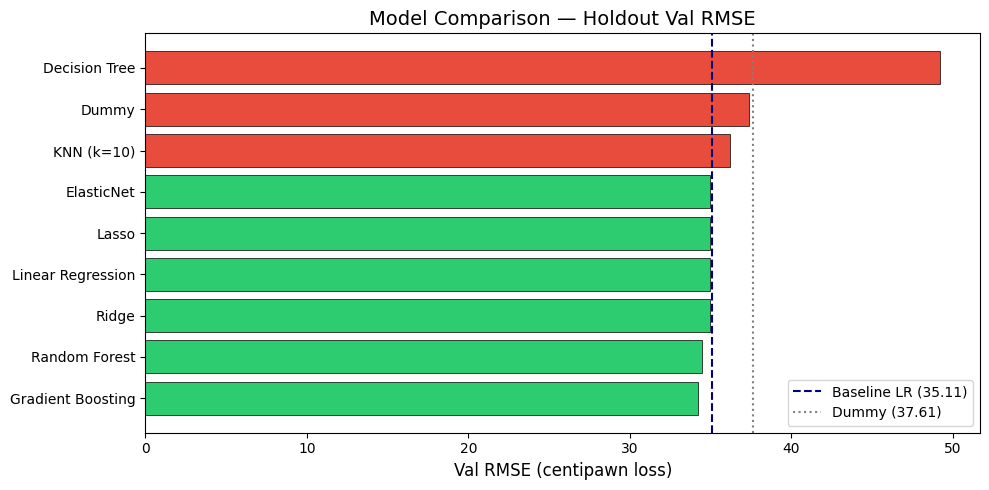

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if r < 35.11 else '#e74c3c' for r in results_df['rmse']]
bars = ax.barh(results_df.index, results_df['rmse'],
               color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(35.11, color='navy', linestyle='--', linewidth=1.5, label='Baseline LR (35.11)')
ax.axvline(37.61, color='gray', linestyle=':', linewidth=1.5, label='Dummy (37.61)')
ax.set_xlabel('Val RMSE (centipawn loss)', fontsize=12)
ax.set_title('Model Comparison — Holdout Val RMSE', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()


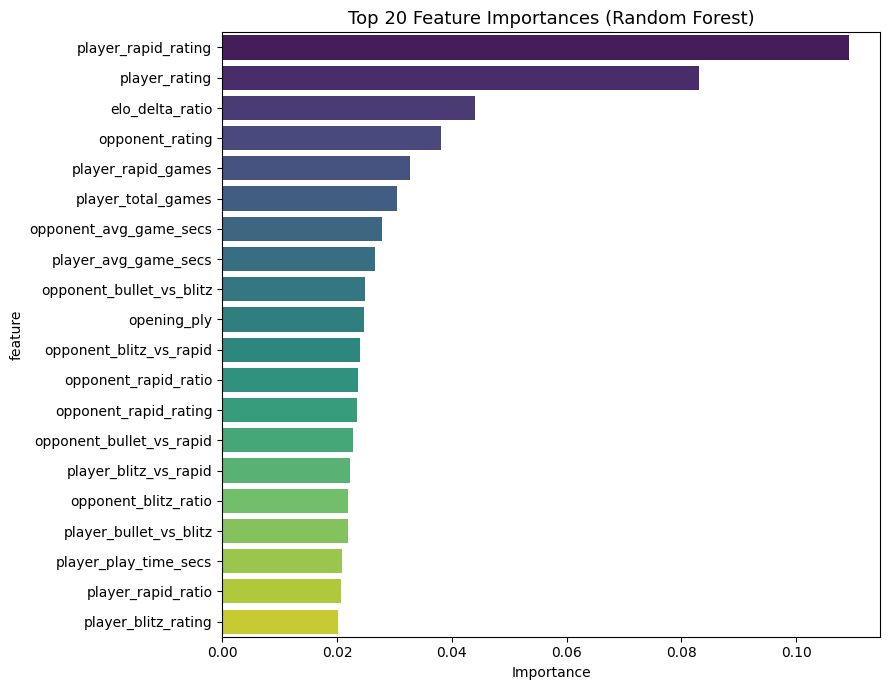

                 feature  importance
     player_rapid_rating    0.109132
           player_rating    0.083118
         elo_delta_ratio    0.044034
         opponent_rating    0.038168
      player_rapid_games    0.032700
      player_total_games    0.030537
  opponent_avg_game_secs    0.027848
    player_avg_game_secs    0.026652
opponent_bullet_vs_blitz    0.024846
             opening_ply    0.024773
 opponent_blitz_vs_rapid    0.023995
    opponent_rapid_ratio    0.023698
   opponent_rapid_rating    0.023415
opponent_bullet_vs_rapid    0.022723
   player_blitz_vs_rapid    0.022306
    opponent_blitz_ratio    0.021857
  player_bullet_vs_blitz    0.021846
   player_play_time_secs    0.020856
      player_rapid_ratio    0.020737
     player_blitz_rating    0.020223


In [17]:
fi_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   RandomForestRegressor(n_estimators=100, random_state=random_state, n_jobs=-1)),
])

fi_pipe.fit(X_train_val, y_train_val)
importances = fi_pipe.named_steps['model'].feature_importances_
feat_names  = X_train_val.columns.tolist()

fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=fi_df, x='importance', y='feature', hue='feature', legend=False, ax=ax, palette='viridis')
ax.set_title('Top 20 Feature Importances (Random Forest)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
print(fi_df.to_string(index=False))

Best Models: <br>
-Gradient Boosting <br>
-Random Forest <br>
-Ridge <br>

Next steps: <br>
-Handle skewness => the best models are the forest models<br> 
-Try alternative imputation <br>
-Consider feature selection <br>
-Add interaction features <br>

The most promising models are : Gradient Boosting, Random Forest and Ridge. <br>
The next steps would be to see whether different imputing strategy would improve the model. <br>
I'll also do hyperparameter tuning to see whether I can yield some results. <br>
I'll also use Cross-Validation. <br>

Check if changing the imputing strategy yields any results

In [ ]:
pipeline = Pipeline([
        ('imputer', KNNImputer(n_neighbors=5)),
        ('scaler',  StandardScaler()),
        ('model',    HistGradientBoostingRegressor(max_iter=200, random_state=random_state)),
    ])

scores = cross_val_score(pipeline, X_train_val, y_train_val,
                         cv=kf, scoring='neg_root_mean_squared_error')
print(f"KNN Imputer  CV RMSE: {-scores.mean():.2f}")

KNN Imputer  CV RMSE: 34.27 ± 0.25


Using KNN Imputer actually made RMSE worse compared to the "default" (34.27 > 34.229319) setup which is Imputing Median

# HyperParameter Tuning

I'll use RandomizedSearchCV as when I run GridSearchCV it is too slow.

In [19]:
pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  HistGradientBoostingRegressor(max_iter=200, random_state=random_state)),
    ])

param_dist = {
    'model__max_iter':      randint(100, 400),
    'model__max_depth':     randint(3, 8),
    'model__learning_rate': uniform(0.01, 0.3),
}

search = RandomizedSearchCV(pipeline, param_dist, n_iter=30, cv=kf,
                             scoring='neg_root_mean_squared_error', n_jobs=-1,
                             random_state=random_state)

search.fit(X_train_val, y_train_val)

print(f"Best params: {search.best_params_}")
print(f"CV RMSE:     {-search.best_score_:.2f}")

Best params: {'model__learning_rate': np.float64(0.027425083650459835), 'model__max_depth': 7, 'model__max_iter': 199}
CV RMSE:     34.19


RMSE on hyperparameter-tuned GradientBoostingModel improved by 34.229319 - 34.19 ~= 0.03 centipawn

# Top Features Only
Using the top 20 features from the Gradient Boosting feature importance analysis to see if reducing dimensionality improves the model.

In [20]:
top_features = fi_df['feature'].tolist()

pipeline_top = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  HistGradientBoostingRegressor(max_iter=200, random_state=random_state)),
])

param_dist_top = {
    'model__max_iter':      randint(100, 400),
    'model__max_depth':     randint(3, 8),
    'model__learning_rate': uniform(0.01, 0.3),
}

search_top = RandomizedSearchCV(pipeline_top, param_dist_top, n_iter=30, cv=kf,
                                scoring='neg_root_mean_squared_error', n_jobs=-1,
                                random_state=random_state)

search_top.fit(X_train_val[top_features], y_train_val)

print(f"Best params: {search_top.best_params_}")
print(f"CV RMSE (top {len(top_features)} features): {-search_top.best_score_:.2f}")
print(f"CV RMSE (all features):                     {-search.best_score_:.2f}")
print(f"Difference: {-search_top.best_score_ - (-search.best_score_):+.2f} centipawn")

Best params: {'model__learning_rate': np.float64(0.027425083650459835), 'model__max_depth': 7, 'model__max_iter': 199}
CV RMSE (top 20 features): 34.20
CV RMSE (all features):                     34.19
Difference: +0.01 centipawn


Actually using  only top 20 features made RMSE slightly bigger

So actually the best model is the Gradient Boost model with all of the columns and tuned hyperparameters

In [21]:
best_model = search.best_estimator_
best_model.fit(X_train_val, y_train_val)

y_pred_test = best_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"Test RMSE (all features):  {test_rmse:.2f}")

Test RMSE (all features):  34.57


# Final Result

Test RMSE (all features):  34.57
CV RMSE (all features):  34.19

Comparing to :
Simple Linear Regression: 
  CV   RMSE: 34.98

Dummy (mean) RMSE: 37.61

My interpretation :
I think there is a little room to improve this model based on the facts that: <br>
-We don't have enough features <br>
-Some features like for example opening_familiarity do not show the whole picture as they were made only based on THIS dataset (It counts how many times a user played that opening in that dataset, not in their whole career) <br>
-Probably there are a lot of other things that influence your accuracy/centipawn loss, like how much have you slept, whether you are on the loose streak etc. <br>
-I think that with this data we can get only this far <br>
-This data set is in some way non-representative of certain type of games. This set has only rapid games and I think that if player would play a blitz/bullet game their accuracy would be much lower compared to rapid or classical. <br>
 
Things that we can do in the next iteration of working on this data: <br>
-Make more data scrapers/mock data reflecting whether you are on the loose streak or not <br>
-Use datascrapers to get more info about player's opening choice<br>
-Maybe somehow label players based on their weaknesses and strenghts. For example some players are more <br> tactical, but others focus on theory and positional gameplay.

What Could I do/What I forgot about:
Handle skewness => I did an expieriment with transforming the values and checking whether it improves Regression model but it doesn't and I lost the notebook.

Check distrbution of each feature and check if it follows distribution that will be present in production => I know that rating follows the same distirbution as in the dataset as well as centipawn loss
 
Make graphs 1:1 feature vs feature, maybe it can show intresting relationships => Essentially more sophisticated DA

Make more advanced model exploration => I haven't considered NN, but considering how long I had to wait for every run of GradientBoost training + KFold + RandomizedSearch, due to time constraints I did not do that